# Multi-objective robust decision-making (MORDM)

This notebook describes how Multi-objective robust decision-making (MORDM) was used to find robust policies to deal with the flood risk of the IJssel river.

The approach for the MORDM consists of four steps:
1. Problem formulation
2. Searching for candidate solutions
3. Re-evaluate candidate solutions under uncertainty
4. Performing a scenario discovery

These four steps are based on 'assignment 9 - MORDM' of the course EPA141A: https://github.com/quaquel/epa141A_open/tree/master/Week%205-6%20-%20robustness%20and%20direct%20search

## Step 1: Problem formulation

First, the model is imported as dike_model using problem formulation 2. Meaning that the outcomes of the model are: ....

For the optimization, the outcomes have a direction in which they are optimized (minimize or maximize). The default of the model is to minimize for all five outcomes. However, for the Environmental interest group minimizing the costs for rfr is not a strict requirement. To take their interests into account, rfr outcome is set as an info variable. Later, in step XXXX rfr costs are added as a constraint to ensure that the projects won't be extremely expensive which would decrease support of other actors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Import EMA Workbench for exploratory modelling and analysis
from ema_workbench import (Policy, ema_logging, MultiprocessingEvaluator, save_results, Scenario, Constraint,
                            ScalarOutcome, Constant, perform_experiments)

from problem_formulation import get_model_for_problem_formulation

from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench.em_framework.samplers import sample_uncertainties

from ema_workbench.em_framework.optimization import (HyperVolume, EpsilonProgress, ArchiveLogger, to_problem)
from ema_workbench.analysis import parcoords

from ema_workbench.util.utilities import (save_results, load_results)
from ema_workbench.analysis import prim

In [2]:
dike_model, planning_steps = get_model_for_problem_formulation(2)

In [3]:
# Check the directions the variables are optimizing to
for outcome in dike_model.outcomes:
    print(f"Outcome: {outcome.name}, Direction: {outcome.kind}")

Outcome: Expected Annual Damage, Direction: -1
Outcome: Dike Investment Costs, Direction: -1
Outcome: RfR Investment Costs, Direction: -1
Outcome: Evacuation Costs, Direction: -1
Outcome: Expected Number of Deaths, Direction: -1


## Step 2: Searching for candidate solutions

To search for candidate solutions a reference scenario has been created. The values of this scenario are XXXX. This reference scenario is used for XXX.

In het bestand dike_model_simulation.py staat ook een reference scenario gedefinieerd:
  reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }


We zouden ook die waarden kunnen gebruiken??
- er is een verschil in het definieren van de ID flood wave shape

In [20]:
reference_scenario = Scenario('reference', **{'discount rate 0': 3.5, 'discount rate 1': 3.5, 'discount rate 2': 3.5, 'A.0_ID flood wave shape': 4,
                                              'A.1_Bmax': 175, 'A.1_pfail': 0.5, 'A.1_Brate': 1.5,
                                              'A.2_Bmax': 175, 'A.2_pfail': 0.5, 'A.2_Brate': 1.5,
                                              'A.3_Bmax': 175, 'A.3_pfail': 0.5, 'A.3_Brate': 1.5,
                                              'A.4_Bmax': 175, 'A.4_pfail': 0.5, 'A.4_Brate': 1.5,
                                              'A.5_Bmax': 175, 'A.5_pfail': 0.5, 'A.5_Brate': 1.5})

In [6]:
# reference_scenario = Scenario('reference', **{'discount rate 0': 2.5, 'discount rate 1': 2.5, 'discount rate 2': 2.5, 'A.0_ID flood wave shape': 75,
#                                               'A.1_Bmax': 190, 'A.1_pfail': 0.5, 'A.1_Brate': 1.5,
#                                               'A.2_Bmax': 190, 'A.2_pfail': 0.5, 'A.2_Brate': 1.5,
#                                               'A.3_Bmax': 190, 'A.3_pfail': 0.5, 'A.3_Brate': 1.5,
#                                               'A.4_Bmax': 190, 'A.4_pfail': 0.5, 'A.4_Brate': 1.5,
#                                               'A.5_Bmax': 190, 'A.5_pfail': 0.5, 'A.5_Brate': 1.5})

## Uitwerkingen van Liss: 4 outcomes

Doe eerst een convergence analysis voor 1 seed en epsilon progress dan kan je een beeld krijgen van het aantal nfe's.

*Met 5 outcomes vind je 29 solutions, met 4 outcomes vind je er maar 3?? bij epsilons van 0.25 en nfe = 500

*voor 4 outcomes bij nfe = 1000 en epsil = 0.01 vind je er maar 4*

*voor 4 outcomes bij nfe = 1000 en epsilon = 0.01 vind je er 8 bij flood ID 4 ipv 75*

* Voor 4 outcomes bij nfe = 10000 en epsilon = 0.01 vind je maar 4 solutions
* voor 4 outcomes bij nfe = 50000 en epsilon = 0.01 vind je 5 solutions: run time = 36m13s *



In [13]:
# Convergence for 1 seed without using ArchiveLoggers
from ema_workbench.em_framework.optimization import ArchiveLogger,EpsilonProgress

ema_logging.log_to_stderr(ema_logging.INFO)

convergence_metrics = [EpsilonProgress()]
nfe = 100
epsilon = [0.01] * (len(dike_model.outcomes)-1)

ema_logging.log_to_stderr(ema_logging.INFO)

with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.optimize(nfe=nfe, searchover='levers', epsilons=epsilon, convergence=convergence_metrics, reference=reference_scenario)

[MainProcess/INFO] pool started with 18 workers
100%|████████████████████████████████████████| 100/100 [00:04<00:00, 22.15it/s]
[MainProcess/INFO] optimization completed, found 8 solutions
[MainProcess/INFO] terminating pool


In [15]:
archive, convergence = results
print(len(archive), 'solutions where found')

8 solutions where found


In [16]:
archive

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,Evacuation Costs,Expected Number of Deaths
0,0,0,0,1,1,1,0,1,0,1,...,7,3,9,5,5,10,3.705564e+06,5.195852e+08,200.690501,0.000976
1,0,0,1,1,1,0,1,0,0,1,...,3,5,10,3,9,6,1.358285e+07,5.422145e+08,0.000000,0.015686
2,1,1,1,1,1,1,1,1,0,0,...,8,2,6,7,9,5,0.000000e+00,5.664076e+08,0.000000,0.000000
3,0,1,1,0,0,0,1,1,1,0,...,3,8,6,6,1,0,2.548189e+06,5.392513e+08,196.991116,0.000356
4,0,0,1,0,1,0,1,1,0,0,...,9,5,7,3,1,2,1.058242e+06,5.423988e+08,64.618862,0.000180
5,1,0,1,1,1,1,1,1,1,1,...,0,1,7,6,6,1,5.543439e+06,4.231382e+08,183.109701,0.002201
6,1,0,0,1,0,1,0,0,1,1,...,0,7,6,7,7,0,7.434614e+06,5.586414e+08,0.000000,0.015706
7,0,0,0,0,0,1,0,0,0,1,...,5,4,5,9,6,4,2.976353e+07,3.415339e+08,0.000000,0.034830


<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
C:\Users\lmvan\AppData\Local\Temp\ipykernel_11648\122905691.py:5: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon$-progress')


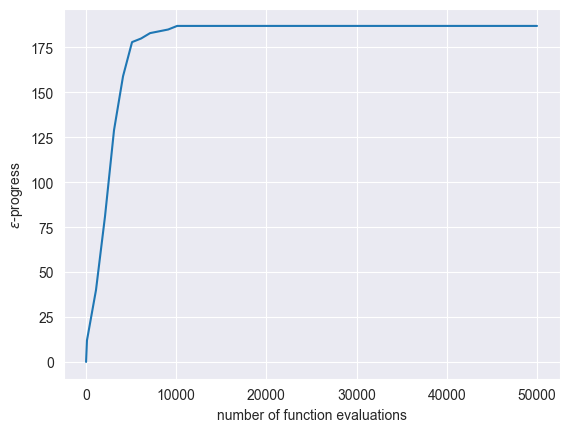

In [8]:
# Plot the convergence of the epsilon progress
archive, convergence = results
fig, ax = plt.subplots()
ax.plot(convergence.nfe, convergence.epsilon_progress)
ax.set_ylabel('$\epsilon$-progress')

ax.set_xlabel('number of function evaluations')
plt.show()

In [7]:
results = []
convergences = []

with MultiprocessingEvaluator(dike_model) as evaluator:
    # run for 5 seeds
    for i in range(5):
        # we create 2 covergence tracker metrics
        # the archive logger writes the archive to disk for every x nfe
        # the epsilon progress tracks during runtime
        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                [l.name for l in dike_model.levers],
                [o.name for o in dike_model.outcomes],
                base_filename=f"{i}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        # 5000 runs is clearly way to low, given the convergence
        # analysis above. this is only for demonstration purposes
        result, convergence = evaluator.optimize(nfe=100, searchover='levers', epsilons=[0.25, 0.25, 0.25, 0.25], convergence=convergence_metrics, reference=reference_scenario)

        results.append(result)
        convergences.append(convergence)

100%|████████████████████████████████████████| 100/100 [00:04<00:00, 22.57it/s]


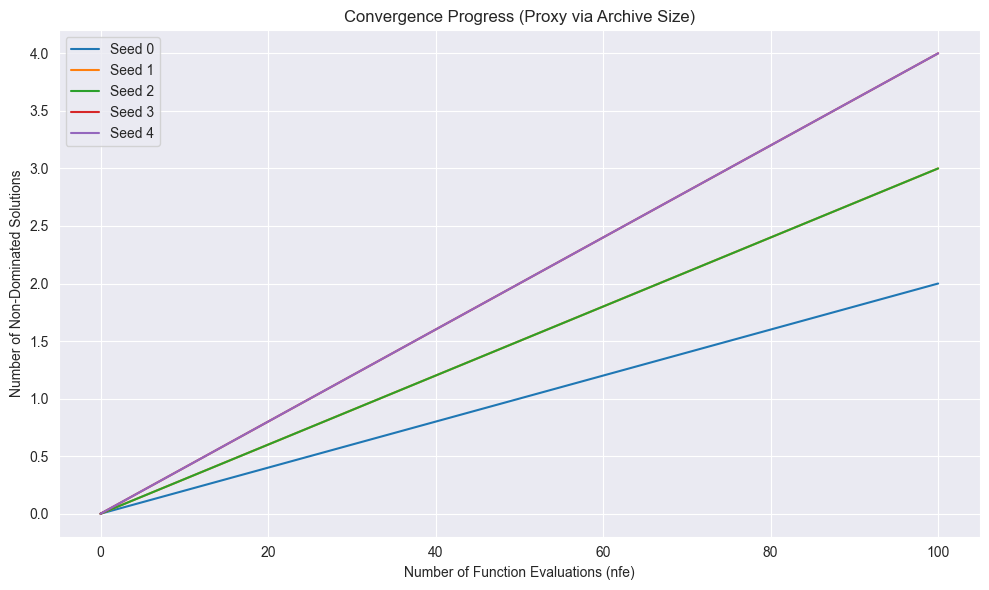

In [9]:
from ema_workbench.em_framework.optimization import ArchiveLogger
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))

# Loop over each saved archive
for i in range(5):
    # Load all intermediate snapshots (each is a DataFrame)
    archives = ArchiveLogger.load_archives(f"./archives/{i}.tar.gz")

    nfe_values = []
    n_pareto_solutions = []

    for nfe, df in archives.items():
        nfe_values.append(nfe)
        n_pareto_solutions.append(len(df))  # you could also calculate epsilon indicator manually here

    # Plot the number of Pareto-optimal solutions over time as a proxy for convergence
    plt.plot(nfe_values, n_pareto_solutions, label=f'Seed {i}')

plt.xlabel('Number of Function Evaluations (nfe)')
plt.ylabel('Number of Non-Dominated Solutions')
plt.title('Convergence Progress (Proxy via Archive Size)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
all_archives = []

for i in range(5):
    archives = ArchiveLogger.load_archives(f"./archives/{i}.tar.gz")
    all_archives.append(archives)

In [69]:
# Build problem object
problem = to_problem(dike_model, searchover="levers")

# Overwrite the NamedObjectMap fields with lists of names
problem.parameters = [param.name for param in dike_model.levers]
problem.outcomes = [outcome.name for outcome in dike_model.outcomes]

In [70]:
print("Problem parameters:", problem.parameters)
print("Result dataframe columns:", all_results_df.columns)

Problem parameters: ['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'EWS_DaysToThreat', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2']
Result dataframe columns: Index(['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
       '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
       '4_RfR 0', '4_RfR 1', '4_RfR 2', 'EWS_DaysToThreat',
       'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
       'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
       'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
       'A.4_D

In [71]:
from ema_workbench.em_framework.optimization import epsilon_nondominated

#problem = to_problem(dike_model, searchover="levers")
reference_set = epsilon_nondominated(results,  epsilons=[0.25, 0.25, 0.25, 0.25, 0.25], problem=problem)

AttributeError: 'str' object has no attribute 'name'

## Uitwerkingen van Eva: 5 outcomes en alleen epsilon progress

In [21]:
# # # Define constrains
# # # expected_annual_damage_limit = 60000000     # expected annual damage
dike_investment_costs_limit = 189926453     # dike investment
# rfr_investment_costs_limit = 710400000      # RfR investment
# #
constraints = [
# #     # Constraint("Expected Annual Damage", outcome_names="Expected Annual Damage",
# #     #            function=lambda x: max(0, x - expected_annual_damage_limit)),
      Constraint("Dike Investment Costs", outcome_names="Dike Investment Costs",
                 function=lambda x: max(0, x - dike_investment_costs_limit))
#      Constraint("RfR Investment Costs", outcome_names="RfR Investment Costs",
#                 function=lambda x: max(0, x - rfr_investment_costs_limit))
# #     # Constraint('Expected Number of Deaths', outcome_names='Expected Number of Deaths',
# #     #            function=lambda x: max(0, x - 0.1))
]


In [22]:
ema_logging.log_to_stderr(ema_logging.INFO)

convergence_metric = [EpsilonProgress()]
epsilons = [0.25] * len([o for o in dike_model.outcomes if o.kind != ScalarOutcome.INFO])

with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.optimize(nfe=100, searchover="levers", epsilons=epsilons, convergence= convergence_metric, reference=reference_scenario)

[MainProcess/INFO] pool started with 18 workers
100%|████████████████████████████████████████| 100/100 [00:04<00:00, 22.30it/s]
[MainProcess/INFO] optimization completed, found 7 solutions
[MainProcess/INFO] terminating pool


In [9]:
archive, convergence = results
print(len(archive), 'solutions where found')

18 solutions where found


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\lmvan\AppData\Local\Temp\ipykernel_9536\2279367247.py:7: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon$-progress')


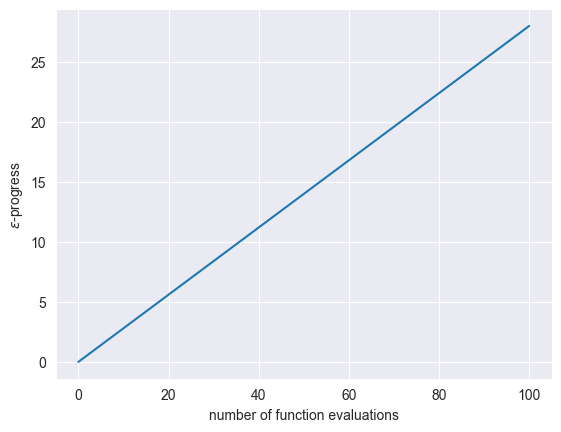

In [10]:
import matplotlib.pyplot as plt
import numpy as np

archive, convergence = results
fig, ax = plt.subplots()
ax.plot(convergence.nfe, convergence.epsilon_progress)
ax.set_ylabel('$\epsilon$-progress')

ax.set_xlabel('number of function evaluations')
plt.show()

In [8]:
results

(    0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0         0        0        1        0        0        0        1        1   
 1         0        1        1        0        0        1        1        0   
 2         0        0        1        1        1        1        1        1   
 3         1        0        1        0        0        0        0        0   
 4         1        1        1        1        0        1        1        0   
 5         0        1        1        0        0        0        1        0   
 6         0        0        1        0        0        0        0        0   
 7         1        1        1        0        0        1        0        0   
 8         0        0        0        1        0        0        1        0   
 9         0        0        0        1        0        1        1        0   
 10        0        0        0        0        0        1        0        1   
 11        1        0        1        0        0    

In [9]:
outcomes, extra_info = results
outcomes

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
0,0,0,1,0,0,0,1,1,0,1,...,4,2,5,5,5,2.108014e+06,7.198692e+08,3.884000e+08,0.000000,0.003619
1,0,1,1,0,0,1,1,0,1,1,...,3,4,7,0,1,2.374907e+07,3.738658e+08,5.696000e+08,1515.371292,0.002472
2,0,0,1,1,1,1,1,1,0,0,...,1,2,10,10,1,1.429718e+07,4.290847e+08,1.176700e+09,611.042333,0.001949
3,1,0,1,0,0,0,0,0,0,1,...,6,1,8,6,0,7.338116e+06,7.315951e+08,2.904000e+08,386.635815,0.000821
4,1,1,1,1,0,1,1,0,1,1,...,4,8,3,0,7,4.740596e+06,4.201887e+08,1.384200e+09,188.084903,0.001042
5,0,1,1,0,0,0,1,0,0,1,...,5,0,1,8,0,8.214602e+06,4.826352e+08,8.333000e+08,405.173134,0.001098
6,0,0,1,0,0,0,0,0,1,0,...,8,9,2,8,4,1.093872e+07,5.463476e+08,4.926000e+08,0.000000,0.009969
7,1,1,1,0,0,1,0,0,1,1,...,0,5,1,2,1,0.000000e+00,5.026456e+08,1.000800e+09,0.000000,0.000000
8,0,0,0,1,0,0,1,0,1,0,...,3,9,3,0,1,0.000000e+00,6.737857e+08,5.216000e+08,0.000000,0.000000
9,0,0,0,1,0,1,1,0,1,1,...,3,9,2,6,0,0.000000e+00,6.361921e+08,6.182000e+08,0.000000,0.000000


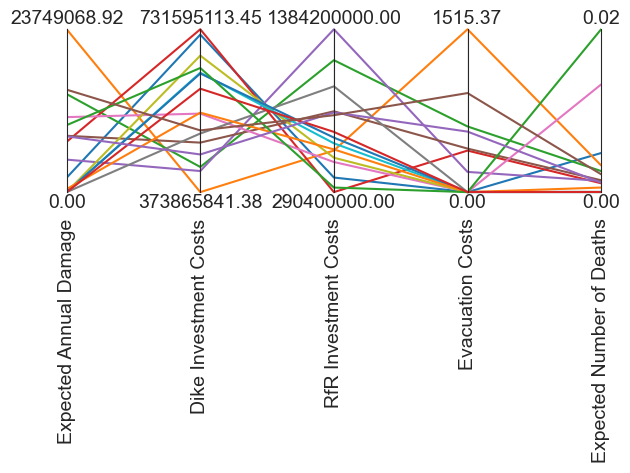

In [10]:
outcomes = outcomes.loc[:, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]]

limits = parcoords.get_limits(outcomes)
axes = parcoords.ParallelAxes(limits)
axes.plot(outcomes)

plt.show()

## Step 3: Re-evaluate candidate solutions under uncertainty

In [11]:
archive

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
0,0,0,1,0,0,0,1,1,0,1,...,4,2,5,5,5,2.108014e+06,7.198692e+08,3.884000e+08,0.000000,0.003619
1,0,1,1,0,0,1,1,0,1,1,...,3,4,7,0,1,2.374907e+07,3.738658e+08,5.696000e+08,1515.371292,0.002472
2,0,0,1,1,1,1,1,1,0,0,...,1,2,10,10,1,1.429718e+07,4.290847e+08,1.176700e+09,611.042333,0.001949
3,1,0,1,0,0,0,0,0,0,1,...,6,1,8,6,0,7.338116e+06,7.315951e+08,2.904000e+08,386.635815,0.000821
4,1,1,1,1,0,1,1,0,1,1,...,4,8,3,0,7,4.740596e+06,4.201887e+08,1.384200e+09,188.084903,0.001042
5,0,1,1,0,0,0,1,0,0,1,...,5,0,1,8,0,8.214602e+06,4.826352e+08,8.333000e+08,405.173134,0.001098
6,0,0,1,0,0,0,0,0,1,0,...,8,9,2,8,4,1.093872e+07,5.463476e+08,4.926000e+08,0.000000,0.009969
7,1,1,1,0,0,1,0,0,1,1,...,0,5,1,2,1,0.000000e+00,5.026456e+08,1.000800e+09,0.000000,0.000000
8,0,0,0,1,0,0,1,0,1,0,...,3,9,3,0,1,0.000000e+00,6.737857e+08,5.216000e+08,0.000000,0.000000
9,0,0,0,1,0,1,1,0,1,1,...,3,9,2,6,0,0.000000e+00,6.361921e+08,6.182000e+08,0.000000,0.000000


In [12]:
logical = (archive['Expected Number of Deaths'] < 0.001) & (archive['RfR Investment Costs'] > 0)
print(np.sum(logical))

archive[logical]

policies = archive[logical]
policies


8


,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
3,1,0,1,0,0,0,0,0,0,1,...,6,1,8,6,0,7.338116e+06,7.315951e+08,2.904000e+08,386.635815,0.000821
7,1,1,1,0,0,1,0,0,1,1,...,0,5,1,2,1,0.000000e+00,5.026456e+08,1.000800e+09,0.000000,0.000000
8,0,0,0,1,0,0,1,0,1,0,...,3,9,3,0,1,0.000000e+00,6.737857e+08,5.216000e+08,0.000000,0.000000
9,0,0,0,1,0,1,1,0,1,1,...,3,9,2,6,0,0.000000e+00,6.361921e+08,6.182000e+08,0.000000,0.000000
10,0,0,0,0,0,1,0,1,1,0,...,1,6,8,9,10,0.000000e+00,6.345262e+08,6.565000e+08,0.000000,0.000000
11,1,0,1,0,0,0,1,0,0,1,...,5,9,6,6,4,4.499500e+05,5.484966e+08,5.772000e+08,0.000000,0.000424
13,0,0,0,0,0,0,1,0,1,0,...,8,5,4,0,8,0.000000e+00,6.010678e+08,6.948000e+08,0.000000,0.000000
14,1,0,1,0,0,1,1,1,0,1,...,9,4,1,1,1,8.141107e+06,4.566022e+08,8.257000e+08,563.194645,0.000876


In [13]:
from ema_workbench import Policy

policies_to_evaluate = []

for i, policy in policies.iterrows():
    policies_to_evaluate.append(Policy(str(i), **policy.to_dict()))
    
n_scenarios = 1000
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios,
                                            policies_to_evaluate)

experiments, outcomes = results


[MainProcess/INFO] pool started with 18 workers
[MainProcess/INFO] performing 1000 scenarios * 8 policies * 1 model(s) = 8000 experiments
100%|██████████████████████████████████████| 8000/8000 [08:30<00:00, 15.67it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [14]:
#save_results(results, 're_evaluation_results.tar.gz') We might need to save the results - I saw this in the example notebooks

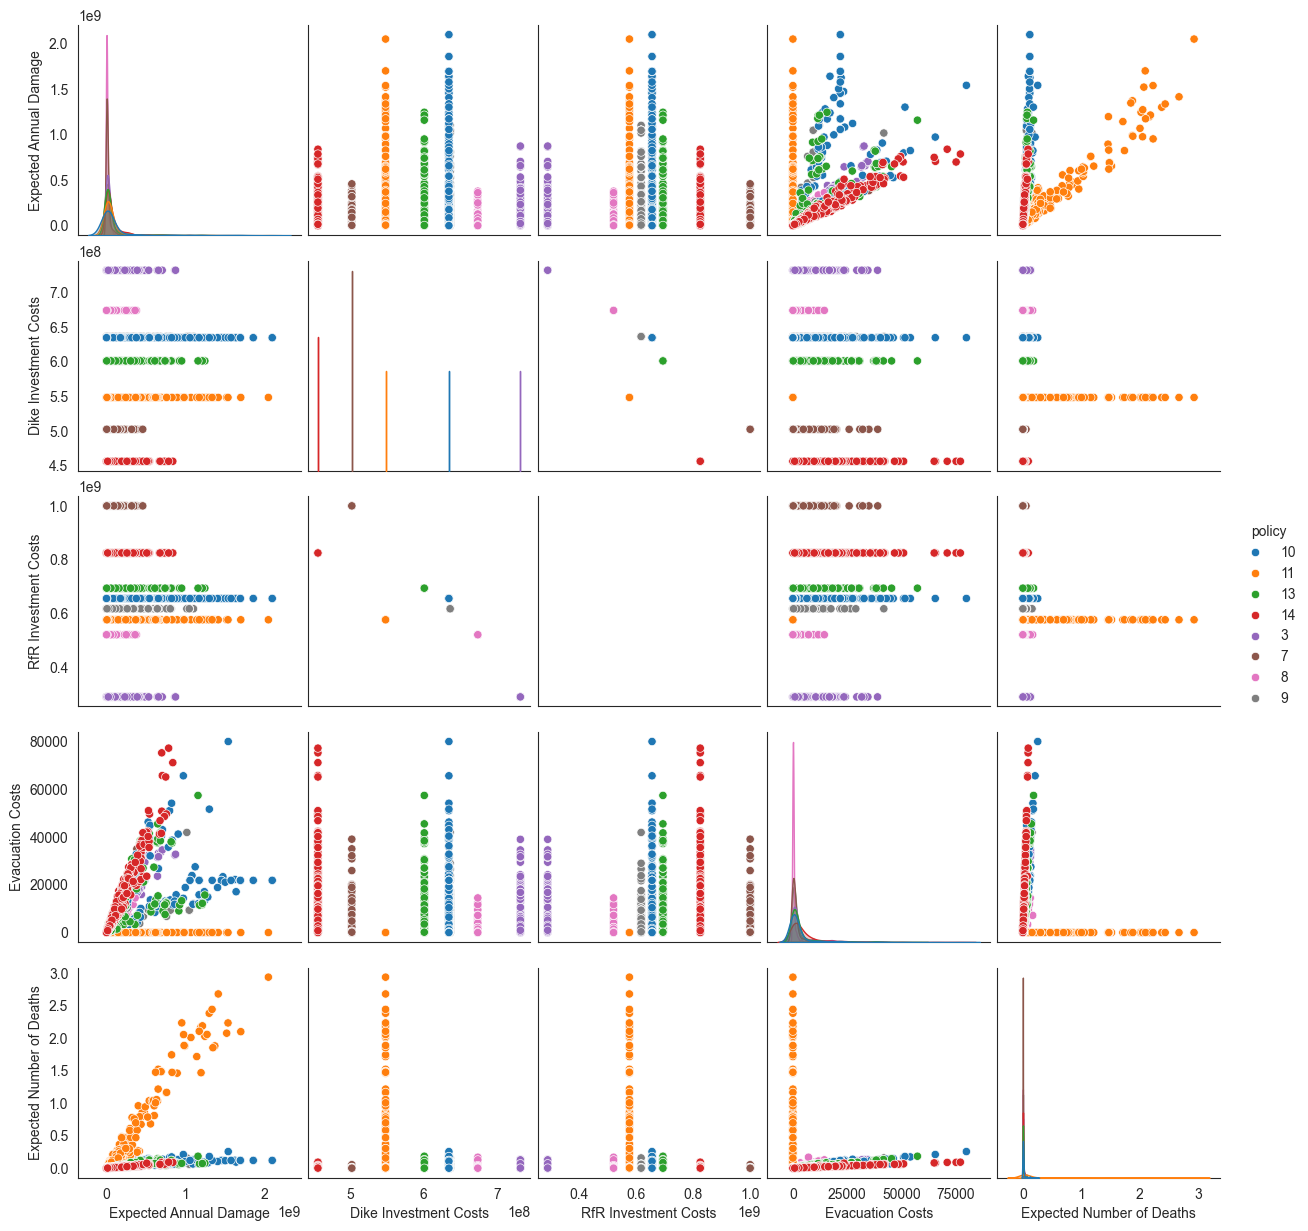

In [15]:
policies = experiments['policy']

data = pd.DataFrame.from_dict(outcomes)
data['policy'] = policies

sns.pairplot(data, hue='policy',  vars=outcomes.keys(), )
plt.show()

## Dit is letterlijk gekopieerd: nog aanpassen!!!
- Kies welke box we willen inspecteren

[MainProcess/INFO] column model dropped from analysis because it has only one category
[MainProcess/INFO] 8000 points remaining, containing 3578 cases of interest
[MainProcess/INFO] mean: 1.0, mass: 0.06275, coverage: 0.1403018446059251, density: 1.0 restricted_dimensions: 9


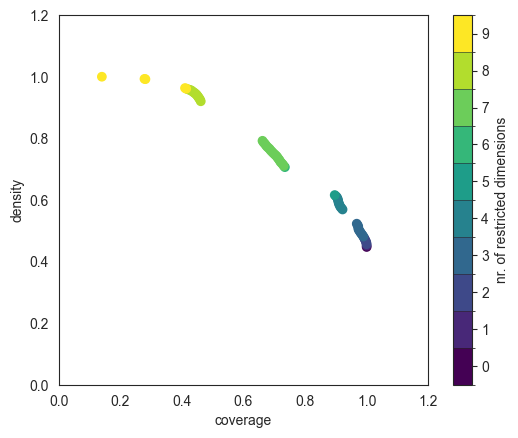

coverage       0.972890
density        0.508918
id            15.000000
k           3481.000000
mass           0.855000
mean           0.508918
n           6840.000000
res_dim        3.000000
Name: 15, dtype: float64

             box 15                                 
                min       max      qp value qp value
A.5_pfail  0.080066  0.999638  2.524516e-08      NaN
A.3_pfail  0.050023  0.999325  9.368899e-05      NaN
A.2_pfail  0.020725  0.999159  7.842436e-02      NaN



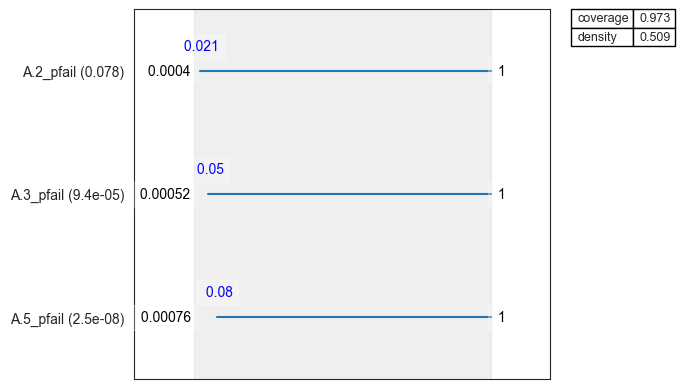

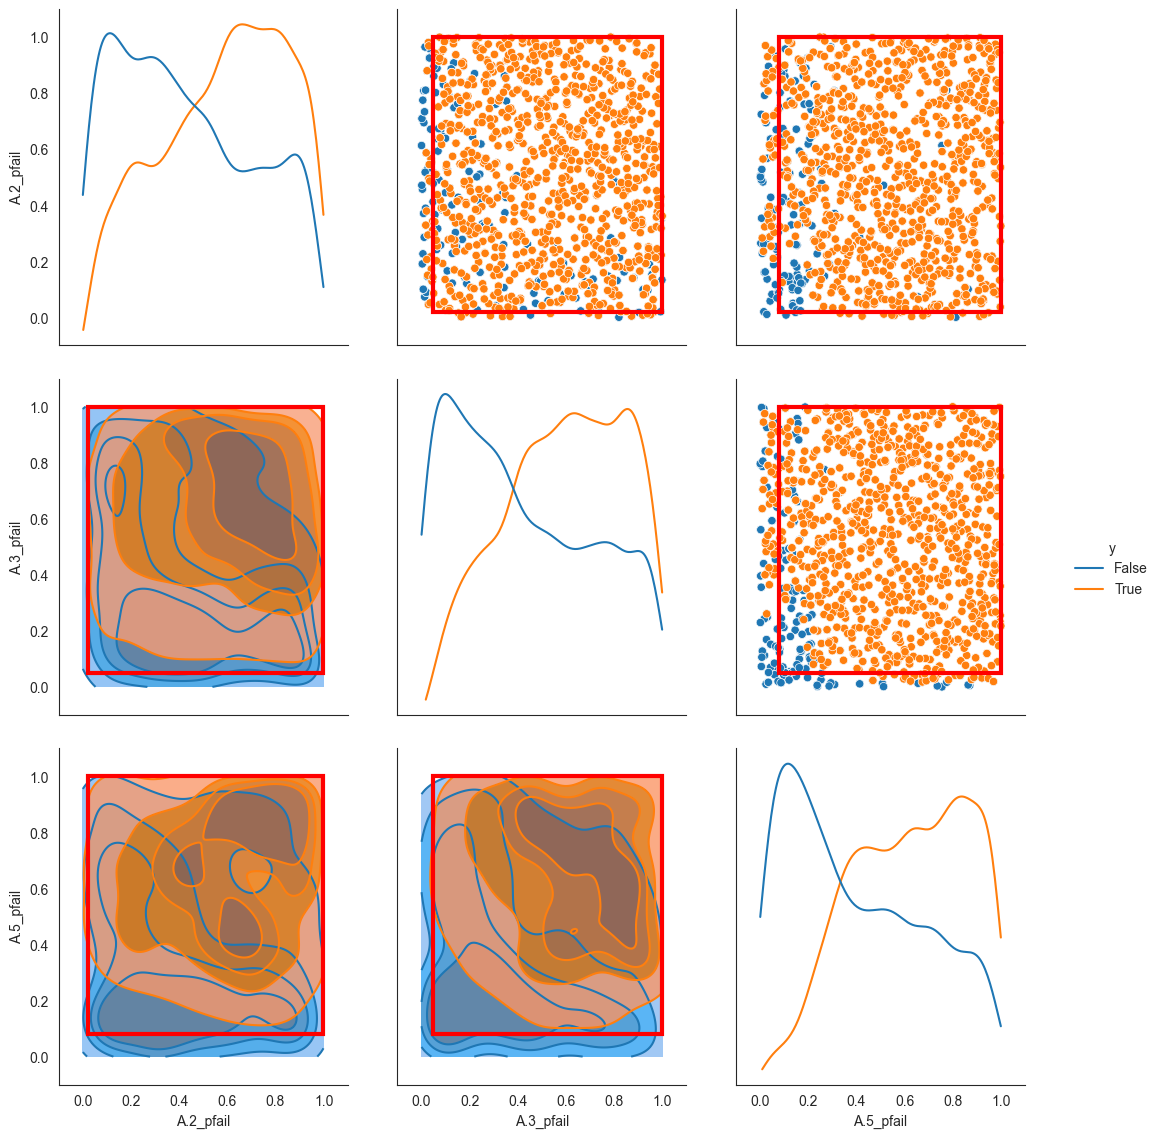

In [18]:
# Clean the experiments for PRIM analysis
experiments_noDI = experiments.drop(labels=[
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2', 
    'policy'
], axis=1)

cleaned_experiments = experiments.drop(labels=[
    '0_RfR 0', '0_RfR 1', '0_RfR 2',
    '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2',
    '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'EWS_DaysToThreat'
], axis=1)

y = (
    (outcomes['Expected Number of Deaths'] < 0.001)
)


# Perform PRIM analysis
prim_alg = prim.Prim(cleaned_experiments, y, threshold=0.5, peel_alpha=0.01)
box = prim_alg.find_box()


# Visualize PRIM results
box.show_tradeoff()
#plt.savefig('prim_tradeoff_density_coverage.png')
plt.show()

box.inspect(15)
box.inspect(15, style='graph')
#plt.savefig('prim_ranges_of_uncertainties.png')
plt.show()

box.select(15)
box.show_pairs_scatter()
fig = plt.gcf()
fig.set_size_inches(12, 12)
#plt.savefig('prim_scatter_plots.png')
plt.show()

In [19]:
def s_to_n(data, direction):
    mean = np.mean(data)
    std = np.std(data)
    
    if direction==ScalarOutcome.MAXIMIZE:
        return mean/std
    else:
        return mean*std
    

In [20]:
experiments, outcomes = results

overall_scores = {}
for policy in np.unique(experiments['policy']):
    scores = {}
    
    logical = experiments['policy']==policy
    
    for outcome in dike_model.outcomes:
        value  = outcomes[outcome.name][logical]
        sn_ratio = s_to_n(value, outcome.kind)
        scores[outcome.name] = sn_ratio
    overall_scores[policy] = scores
scores = pd.DataFrame.from_dict(overall_scores).T
scores

,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
10,3.451749e+16,75.641419,0.0,2.897211e+07,0.000397
11,1.733655e+16,65.385885,0.0,0.000000e+00,0.044491
13,9.774747e+15,71.652862,0.0,1.979319e+07,0.000185
14,9.015729e+15,27.215610,0.0,5.395653e+07,0.000107
3,5.883714e+15,87.212934,0.0,1.835738e+07,0.000139
7,1.009386e+15,29.960013,0.0,4.821117e+06,0.000012
8,4.382442e+14,0.000000,0.0,4.576446e+05,0.000054
9,7.668637e+15,0.000000,0.0,6.667109e+06,0.000070


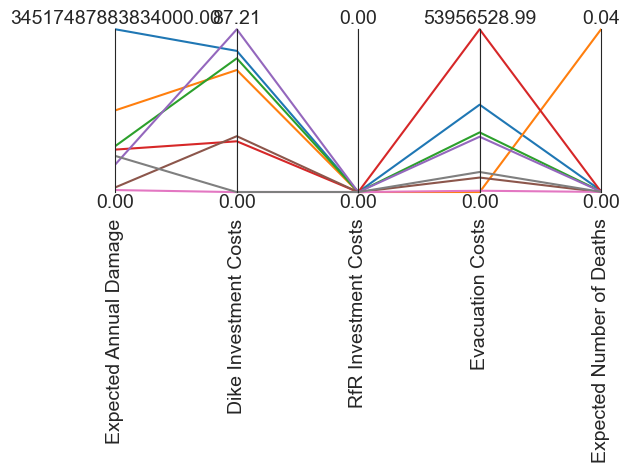

In [21]:
from ema_workbench.analysis import parcoords

data = scores
limits = parcoords.get_limits(data)
limits.loc[0, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]] = 0

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)
plt.show()

In [22]:
def calculate_regret(data, best):
    return np.abs(best-data)

In [23]:
experiments, outcomes = results

overall_regret = {}
max_regret = {}
for outcome in dike_model.outcomes:
    policy_column = experiments['policy']
    
    # create a DataFrame with all the relevent information
    # i.e., policy, scenario_id, and scores
    data = pd.DataFrame({outcome.name: outcomes[outcome.name], 
                         "policy":experiments['policy'],
                         "scenario":experiments['scenario']})
    
    # reorient the data by indexing with policy and scenario id
    data = data.pivot(index='scenario', columns='policy')
    
    # flatten the resulting hierarchical index resulting from 
    # pivoting, (might be a nicer solution possible)
    data.columns = data.columns.get_level_values(1)
    
    # we need to control the broadcasting. 
    # max returns a 1d vector across scenario id. By passing
    # np.newaxis we ensure that the shape is the same as the data
    # next we take the absolute value
    #
    # basically we take the difference of the maximum across 
    # the row and the actual values in the row
    #
    outcome_regret = (data.max(axis=1).values[:, np.newaxis] - data).abs()
    
    overall_regret[outcome.name] = outcome_regret
    max_regret[outcome.name] = outcome_regret.max()
    

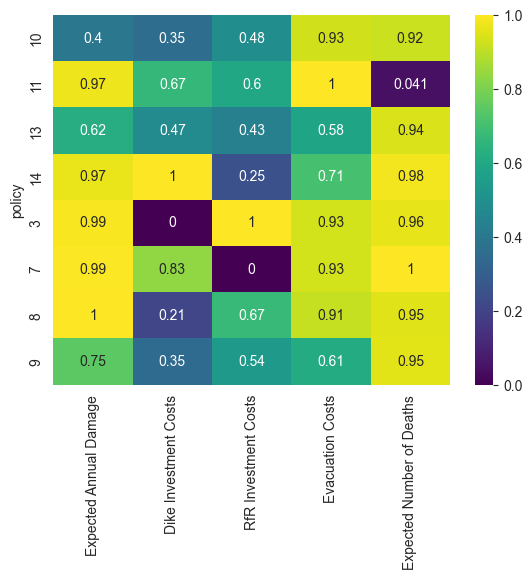

In [24]:
import seaborn as sns

max_regret = pd.DataFrame(max_regret)
sns.heatmap(max_regret/max_regret.max(), cmap='viridis', annot=True)
plt.show()

IndexError: list index out of range

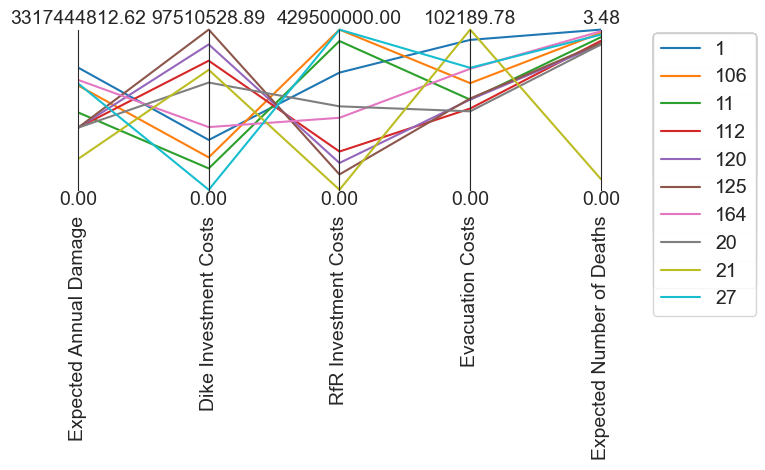

In [32]:

colors = sns.color_palette()

data = max_regret

# makes it easier to identify the policy associated with each line
# in the parcoords plot
# data['policy'] = data.index.astype("float64")

limits = parcoords.get_limits(data)
limits.loc[0, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]] = 0

paraxes = parcoords.ParallelAxes(limits)

for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i])
    paraxes.legend()
    
plt.show()

In [25]:
from collections import defaultdict

policy_regret = defaultdict(dict)
for key, value in overall_regret.items():
    for policy in value:
        policy_regret[policy][key] = value[policy]

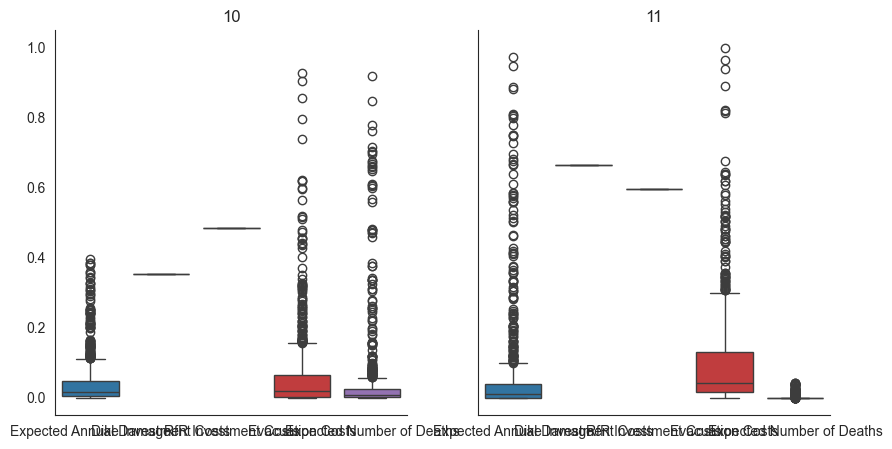

In [26]:
# this generates a 2 plots with a shared y and x axis
fig, axes = plt.subplots(ncols=2, figsize=(10,5), 
                         sharey=True, sharex=True)

# to ensure easy iteration over the axes grid, we turn it
# into a list. Because there are four plots, I hard coded
# this. 


# zip allows us to zip together the list of axes and the list of 
# key value pairs return by items. If we iterate over this
# it returns a tuple of length 2. The first item is the ax
# the second items is the key value pair.
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)

    # we need to scale the regret to ensure fair visual
    # comparison. We can do that by divding by the maximum regret
    data = data/max_regret.max(axis=0)
    sns.boxplot(data=data, ax=ax)
    
    # removes top and left hand black outline of axes
    sns.despine()
    
    # ensure we know which policy the figure is for
    ax.set_title(str(policy))
plt.show()

## Step 4: Using scenario discovery to detect the vulnerabilities of the candidate solutions and improving the candidate solutions